<a href="https://colab.research.google.com/github/nikasvesko/repic/blob/main/seminar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Seminar

O datasetu:

-1697 žena

-22 varijable

-podatci su kombinacija numeričkih i kategorijskih varijabli

Skup podataka odnosi se na faktore rizika i dijagnostičke pokazatelje raka dojke.

Ciljna varijabla je cancer, koja označava ima li osoba dijagnosticiran rak (Yes/No).

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/nikasvesko/repic/main/CubanDataset.csv", index_col=0) #da id bude indeks

data.head()

,age,menarche,menopause,agefirst,children,breastfeeding,nrelbc,biopsies,hyperplasia,race,...,weight,exercise,alcohol,tobacco,allergies,emotional,depressive,histologicalclass,birads,cancer
id,,,,,,,,,,,,,,,,,,,,,
1,50,11,No,No,0,No,Mother,1.0,Yes,White,...,83.4,No,Yes,Yes,Rhinitis,Sad,Yes,3.0,3A,Yes
2,46,12,No,36,1,3 months,Mother/Sister,2.0,Yes,Mixed,...,78.2,2,Yes,No,Medicines,Joy,No,3.0,3B,Yes
3,47,13,No,26,1,3 months,Sister,1.0,Yes,Black,...,82.6,1,No,Yes,Laryngitis,Sad,No,4.0,3B,Yes
4,49,11,47,21,1,No,Daughter,1.0,No,Black,...,79.4,No,Yes,Yes,No,Joy,No,3.0,4B,Yes
5,54,14,42,16,1,1 month,Mother,2.0,Yes,White,...,81.5,No,Yes,No,No,Sad,Yes,4.0,3C,Yes


In [ ]:
#prebacujem zavisnu varijablu u binarnu
data['cancer'] = data['cancer'].map({'Yes': 1, 'No': 0})
data.head()

,age,menarche,menopause,agefirst,children,breastfeeding,nrelbc,biopsies,hyperplasia,race,...,weight,exercise,alcohol,tobacco,allergies,emotional,depressive,histologicalclass,birads,cancer
id,,,,,,,,,,,,,,,,,,,,,
1,50,11,No,No,0,No,Mother,1.0,Yes,White,...,83.4,No,Yes,Yes,Rhinitis,Sad,Yes,3.0,3A,1
2,46,12,No,36,1,3 months,Mother/Sister,2.0,Yes,Mixed,...,78.2,2,Yes,No,Medicines,Joy,No,3.0,3B,1
3,47,13,No,26,1,3 months,Sister,1.0,Yes,Black,...,82.6,1,No,Yes,Laryngitis,Sad,No,4.0,3B,1
4,49,11,47,21,1,No,Daughter,1.0,No,Black,...,79.4,No,Yes,Yes,No,Joy,No,3.0,4B,1
5,54,14,42,16,1,1 month,Mother,2.0,Yes,White,...,81.5,No,Yes,No,No,Sad,Yes,4.0,3C,1


In [ ]:
X = data.iloc[:, :-1] #nezavisne
y = data.iloc[:, -1] #ciljna
X.head()

,age,menarche,menopause,agefirst,children,breastfeeding,nrelbc,biopsies,hyperplasia,race,...,imc,weight,exercise,alcohol,tobacco,allergies,emotional,depressive,histologicalclass,birads
id,,,,,,,,,,,,,,,,,,,,,
1,50,11,No,No,0,No,Mother,1.0,Yes,White,...,27.6,83.4,No,Yes,Yes,Rhinitis,Sad,Yes,3.0,3A
2,46,12,No,36,1,3 months,Mother/Sister,2.0,Yes,Mixed,...,27.3,78.2,2,Yes,No,Medicines,Joy,No,3.0,3B
3,47,13,No,26,1,3 months,Sister,1.0,Yes,Black,...,24.6,82.6,1,No,Yes,Laryngitis,Sad,No,4.0,3B
4,49,11,47,21,1,No,Daughter,1.0,No,Black,...,28.6,79.4,No,Yes,Yes,No,Joy,No,3.0,4B
5,54,14,42,16,1,1 month,Mother,2.0,Yes,White,...,28.4,81.5,No,Yes,No,No,Sad,Yes,4.0,3C


In [ ]:
y.head()

,cancer
id,
1,1
2,1
3,1
4,1
5,1


In [ ]:
#nrelbc cu pretvorit u obiteljsku povijest

X['nrelbc_binary'] = X['nrelbc'].apply(lambda x: 0 if x == 'No' else 1)
X = X.drop(columns=['nrelbc'])
#ima li netko obiteljsku povijest ili nema

In [ ]:
#lažno num u brojeve
to_numeric_cols = ['menopause', 'agefirst', 'children', 'breastfeeding', 'birads']

for c in to_numeric_cols:
    if c in X.columns:
        X[c] = pd.to_numeric(X[c], errors='coerce') #errors='coerce' će sve što ne može pretvoriti u broj staviti na NaN


In [ ]:
#pretvori kategoricke u numericke
cat_cols = X.select_dtypes(include='object').columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded.head()

,age,menarche,menopause,agefirst,children,breastfeeding,biopsies,year,imc,weight,...,allergies_No,allergies_Other,allergies_Rhinitis,allergies_Rhinitis/Laryngitis,allergies_Rhinitis/Laryngitis/Medicines,allergies_Rhinitis/Laryngitis/Other,allergies_Rhinitis/Medicines,allergies_Rhinitis/Other,emotional_Sad,depressive_Yes
id,,,,,,,,,,,,,,,,,,,,,
1,50,11,NaN,NaN,0.0,NaN,1.0,2011.0,27.6,83.4,...,False,False,True,False,False,False,False,False,True,True
2,46,12,NaN,36.0,1.0,NaN,2.0,2013.0,27.3,78.2,...,False,False,False,False,False,False,False,False,False,False
3,47,13,NaN,26.0,1.0,NaN,1.0,2011.0,24.6,82.6,...,False,False,False,False,False,False,False,False,True,False
4,49,11,47.0,21.0,1.0,NaN,1.0,2011.0,28.6,79.4,...,True,False,False,False,False,False,False,False,False,False
5,54,14,42.0,16.0,1.0,NaN,2.0,2007.0,28.4,81.5,...,True,False,False,False,False,False,False,False,True,True


In [ ]:
X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce') #errors='coerce' će sve što ne može pretvoriti u broj staviti na NaN
#pretvaranje u int ili float-> numeric

In [ ]:
#imputacija
X.isna().sum()

,0
age,0
menarche,0
menopause,0
agefirst,0
children,0
breastfeeding,0
biopsies,1
hyperplasia,0
race,0
year,537


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan,
                       strategy='median')
imputer

SimpleImputer(strategy='median')

In [ ]:
imputer.fit(X_encoded)
imputer.statistics_

array([5.300e+01, 1.200e+01, 4.400e+01, 2.300e+01, 1.000e+00, 6.000e+00,
       1.000e+00, 2.011e+03, 2.510e+01, 6.920e+01, 3.000e+00, 6.000e+00,
       1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00])

In [ ]:
X_imputed = imputer.transform(X_encoded)

In [ ]:
X_encoded.median()

,0
age,53.0
menarche,12.0
menopause,44.0
agefirst,23.0
children,1.0
breastfeeding,6.0
biopsies,1.0
year,2011.0
imc,25.1
weight,69.2


In [ ]:
X_imp = pd.DataFrame(imputer.fit_transform(X_encoded),
                     columns=X_encoded.columns,
                     index=X_encoded.index)

X_imp.head()

,age,menarche,menopause,agefirst,children,breastfeeding,biopsies,year,imc,weight,...,allergies_No,allergies_Other,allergies_Rhinitis,allergies_Rhinitis/Laryngitis,allergies_Rhinitis/Laryngitis/Medicines,allergies_Rhinitis/Laryngitis/Other,allergies_Rhinitis/Medicines,allergies_Rhinitis/Other,emotional_Sad,depressive_Yes
id,,,,,,,,,,,,,,,,,,,,,
1,50.0,11.0,44.0,23.0,0.0,6.0,1.0,2011.0,27.6,83.4,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,46.0,12.0,44.0,36.0,1.0,6.0,2.0,2013.0,27.3,78.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47.0,13.0,44.0,26.0,1.0,6.0,1.0,2011.0,24.6,82.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,49.0,11.0,47.0,21.0,1.0,6.0,1.0,2011.0,28.6,79.4,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,54.0,14.0,42.0,16.0,1.0,6.0,2.0,2007.0,28.4,81.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
X_imp.describe()

,age,menarche,menopause,agefirst,children,breastfeeding,biopsies,year,imc,weight,...,allergies_No,allergies_Other,allergies_Rhinitis,allergies_Rhinitis/Laryngitis,allergies_Rhinitis/Laryngitis/Medicines,allergies_Rhinitis/Laryngitis/Other,allergies_Rhinitis/Medicines,allergies_Rhinitis/Other,emotional_Sad,depressive_Yes
count,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,...,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000
mean,51.483206,11.725987,36.855038,22.759576,0.995875,6.327048,1.308191,2010.906895,25.532823,70.489570,...,0.269888,0.046553,0.166176,0.001179,0.001179,0.000589,0.000589,0.000589,0.456099,0.430171
std,11.929919,1.839937,17.939435,6.782326,0.921753,4.611658,1.184067,3.833142,4.951383,12.771422,...,0.444032,0.210741,0.372348,0.034320,0.034320,0.024275,0.024275,0.024275,0.498216,0.495246
min,20.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2001.000000,5.000000,13.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,10.000000,41.000000,21.000000,0.000000,6.000000,0.000000,2010.000000,22.800000,62.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,12.000000,44.000000,23.000000,1.000000,6.000000,1.000000,2011.000000,25.100000,69.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,61.000000,13.000000,47.000000,26.000000,2.000000,6.000000,2.000000,2014.000000,27.300000,79.200000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,90.000000,17.000000,60.000000,46.000000,5.000000,72.000000,5.000000,2018.000000,88.800000,240.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
y.describe()

,cancer
count,1697.000000
mean,0.683559
std,0.465224
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
X_imp.corrwith(y).sort_values(ascending=False)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
biopsies,0.714473
menopause,0.672797
emotional_Sad,0.579811
exercise_No,0.578469
alcohol_Yes,0.571576
tobacco_Yes,0.544601
hyperplasia_Yes,0.503424
depressive_Yes,0.427378
nrelbc_binary,0.415272
allergies_No,0.413671


In [ ]:
X_imp = X_imp.drop(columns=['birads', 'biopsies', 'histologicalclass', 'year', 'hyperplasia_Yes'])

Statistika

In [ ]:
!pip install pingouin
import pingouin as pg

In [ ]:
pg.normality(data, dv='age', group='cancer') #test normalnosti pokazao je odstupanje od normalne distribucije

,W,pval,normal
cancer,,,
1,0.962689,1.150346e-16,False
0,0.978728,4.769157e-07,False


In [ ]:
#t test
#Razlikuje li se prosječna dob između skupine s rakom i bez raka?
pg.ttest(
    X_imp.loc[y == 0, 'age'],
    X_imp.loc[y == 1, 'age'],
    correction=True
)
#p < 0.05 → postoji statistički značajna razlika u dobi između skupina, skupina s rakom je starija


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-13.590385,800.173748,two-sided,5.312122e-38,"[-10.22, -7.64]",0.798711,3.629e+36,NaN


In [ ]:
tab = pd.crosstab(X_imp['nrelbc_binary'], y) #kontingencijska tablica
tab

cancer,0,1
nrelbc_binary,,
0.0,421,392
1.0,116,768


In [ ]:
#Chi square test
#Je li obiteljska povijest raka dojke povezana s pojavom raka dojke?
tmp = pd.DataFrame({
    'nrelbc_binary': X_imp['nrelbc_binary'],
    'cancer': y
})

pg.chi2_independence(
    data=tmp,
    x='nrelbc_binary',
    y='cancer'
)  #χ² = 290.86, p < 0.001, postoji statistički značajna povezanost

(cancer                  0           1
 nrelbc_binary                        
 0.0            257.266352  555.733648
 1.0            279.733648  604.266352,
 cancer             0      1
 nrelbc_binary              
 0.0            420.5  392.5
 1.0            116.5  767.5,
                  test    lambda        chi2  dof          pval    cramer  \
 0             pearson  1.000000  290.863893  1.0  3.223464e-65  0.414003   
 1        cressie-read  0.666667  293.165895  1.0  1.015662e-65  0.415639   
 2      log-likelihood  0.000000  303.183736  1.0  6.670440e-68  0.422680   
 3       freeman-tukey -0.500000  316.151317  1.0  9.982591e-71  0.431625   
 4  mod-log-likelihood -1.000000  334.784010  1.0  8.726619e-75  0.444162   
 5              neyman -2.000000  394.682764  1.0  7.914968e-88  0.482262   
 
    power  
 0    1.0  
 1    1.0  
 2    1.0  
 3    1.0  
 4    1.0  
 5    1.0  )

Model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imp,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   #stratify=y osigurava da u train i test skupu bude isti omjer klase 0 i 1 kao u originalu
)


In [ ]:
#skaliranje
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#X_train= scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    criterion = 'gini',
    random_state=42,
    class_weight = 'balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
cm


array([[106,   2],
       [  1, 231]])

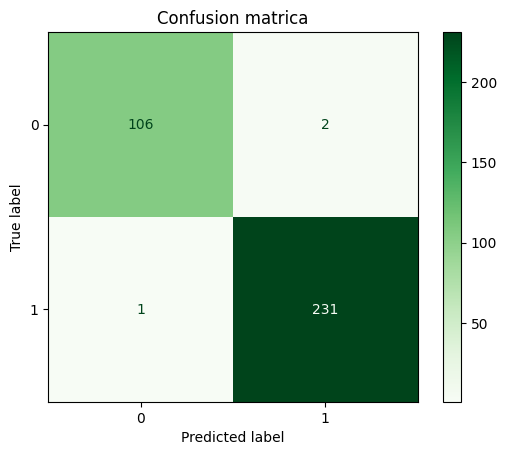

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap = 'Greens')
plt.title('Confusion matrica')
plt.show()

In [ ]:
accuracy_score(y_test, y_pred)

0.9911764705882353

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_imp.columns)
importances.sort_values(ascending=False).head(10)
#ovdje sam isla vidjet u biti ako imam data leakage, ali izgleda okej

,0
menopause,0.173929
exercise_No,0.148072
breastfeeding,0.132953
alcohol_Yes,0.091119
tobacco_Yes,0.074271
allergies_No,0.063204
children,0.053146
depressive_Yes,0.043268
nrelbc_binary,0.041660
age,0.035817
